# Phân tích spam và seeding cho hệ thống đánh giá thương mại điện tử

**Dự án:** Multimodal Review Analytics Dashboard  
**Đầu vào:** File `scraping_agent/data/all_reviews.csv` chứa các đánh giá đã được nhóm cào từ Tiki, Lazada, Thế Giới Di Động.  
**Đầu ra:** File `data/processed/reviews_flagged.csv` với 1 cột mới `is_spam` (0 = sạch, 1 = spam).

## Mục tiêu của notebook


1. **Tiền xử lý văn bản** — chuẩn hóa unicode, làm sạch HTML/URL/mention/hashtag, đo tỉ lệ từ vựng thay đổi qua từng bước.
2. **Áp dụng bộ luật rule-based** — 17 luật được nhóm theo 4 trục: cấu trúc văn bản, mẫu khuôn, đặc thù sàn TMĐT, bất thường rating-text. Cộng thêm phát hiện trùng lặp seeding bằng TF-IDF + Cosine Similarity.
3. **Phân tích khám phá EDA** — thống kê mô tả, phân tích phân bố nhãn, phân tích mối quan hệ giữa các thuộc tính, phân tích phân phối Zipf, word cloud, type-token ratio, kiểm định Mann-Whitney U, vector hóa và t-SNE 2D.

## Bộ luật 

| Luật | Lý do  |
|------|-------------|
| Bình luận nhận xu | Shopee và Tiki có chương trình thưởng coin, nhiều người gõ bừa cho đủ ký tự |
| Chứa thông tin liên hệ | Sđt / Zalo / FB là chiêu chuyển hướng giao dịch ra ngoài sàn |
| Chứa link bên ngoài | Review thật hầu như không có URL |
| Quảng cáo shop đối thủ | Bắt các review kiểu "qua bên kia rẻ hơn" |
| Mã giảm giá rác | Bắt các review chèn voucher / promo code lung tung |
| Lặp từ liên tục | Bắt kiểu spam câu chữ "tốt tốt tốt tốt tốt" |
| Quá nhiều ký tự đặc biệt | Bắt kiểu spam ký hiệu loạn xạ |
| Quá nhiều chữ in hoa | Bắt kiểu hét lên / quảng cáo |
| Chỉ số và dấu câu | Bắt review không có chữ cái |

## 1. Preparing the Environment

Load the necessary libraries and configure the chart to display Vietnamese characters. The main parameters are set here to ensure consistent display throughout.

In [45]:
# Fix console encoding for Windows if necessary
import sys
if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8")

from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

# Add the project root directory to the path for importing the ai_engine module
ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from IPython.display import display, Markdown
from scipy import stats as scipy_stats

# Configure matplotlib fonts with multilingual character support
matplotlib.rcParams["font.family"] = ["Segoe UI", "Arial", "DejaVu Sans", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 130

# Core color scheme used consistently throughout the notebook
COLOR_CLEAN = "#27ae60"      # Green - represents legitimate content
COLOR_SPAM = "#e74c3c"       # Red - represents spam content
COLOR_NEUTRAL = "#3498db"    # Blue - general informational elements
COLOR_HIGHLIGHT = "#f39c12"  # Orange - emphasis and highlighting

# Multi-color palettes for visualizations with multiple categories
PALETTE_MULTI = "viridis"
PALETTE_HEAT = "rocket_r"
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.05)

print("All required libraries and visualization settings have been successfully initialized")

All required libraries and visualization settings have been successfully initialized


In [46]:
# Import spam detection functions implemented in the spam_filter module
from ai_engine.text_processing.spam_filter import (
    detect_spam,
    summarize_spam,
    normalize_pipeline,
    normalize_text,
    remove_emojis,
    count_words,
    count_chars,
    get_emoji_ratio,
    get_special_char_ratio,
    get_uppercase_ratio,
    get_digit_ratio,
    get_type_token_ratio,
)

print("Spam detection functions have been successfully imported from the spam_filter module")

Spam detection functions have been successfully imported from the spam_filter module


## 2. Loading Raw Data

The input data is a CSV file containing all the reviews collected by the team from three e-commerce platforms. Each line is a comment with basic information such as text content, star rating, product URL, and posting date.

In [47]:
# Define the path to the raw dataset and the output location for processed results
INPUT_CSV = ROOT / "scraping_agent" / "data" / "all_reviews.csv"
OUTPUT_DIR = ROOT / "data" / "processed"
OUTPUT_CSV = OUTPUT_DIR / "reviews_flagged.csv"

# Read the file using utf-8-sig encoding to ensure proper handling of Vietnamese characters (Windows BOM)
df_raw = pd.read_csv(INPUT_CSV, encoding="utf-8-sig")

print(f"File successfully loaded: {INPUT_CSV.name}")
print(f"Total number of reviews: {len(df_raw):,}")
print(f"Available columns in the dataset: {list(df_raw.columns)}")

File successfully loaded: all_reviews.csv
Total number of reviews: 9,386
Available columns in the dataset: ['product_name', 'text', 'rating', 'date', 'image_urls', 'product_url', 'scraped_at']


### 2.1. Reviewing the First Few Lines

Before preprocessing, let's quickly look at the data format and check if the columns have reasonable values.

In [48]:
display(df_raw.head(5))

,product_name,text,rating,date,image_urls,product_url,scraped_at
0,Sách Thầm Yêu Ánh Dương Rực Rỡ,Đọc quá trời hay luôn á 5⭐️ Kh có ảnh nên lấy đại,5,2026-04-24,https://salt.tikicdn.com/ts/review/b0/35/30/e5...,https://tiki.vn/dien-thoai-samsung-galaxy-a36-...,2026-04-29T23:49:44.380507
1,Sách Thầm Yêu Ánh Dương Rực Rỡ,"Hay nha, sẽ ủng hộ dài dài, đóng gói oki",5,2026-04-21,https://salt.tikicdn.com/ts/review/3b/db/ac/ee...,https://tiki.vn/dien-thoai-samsung-galaxy-a36-...,2026-04-29T23:49:44.380617
2,Sách Thầm Yêu Ánh Dương Rực Rỡ,NaN,5,2026-04-18,NaN,https://tiki.vn/dien-thoai-samsung-galaxy-a36-...,2026-04-29T23:49:44.380634
3,Sách Thầm Yêu Ánh Dương Rực Rỡ,NaN,5,2026-04-03,NaN,https://tiki.vn/dien-thoai-samsung-galaxy-a36-...,2026-04-29T23:49:44.380658
4,Sách Thầm Yêu Ánh Dương Rực Rỡ,"Nội dung gần gũi, sách đẹp, giao hàng nhanh, đ...",5,2026-03-12,NaN,https://tiki.vn/dien-thoai-samsung-galaxy-a36-...,2026-04-29T23:49:44.380672


### 2.2. Statistics on Missing Data Rate

The two core columns for spam filtering are `text` and `rating`. If a significant number of data are missing, they need to be processed before being fed into the pipeline.

In [49]:
# Compute the number and proportion of missing values for each column
missing_count = df_raw.isna().sum()
missing_pct = (df_raw.isna().mean() * 100).round(2)

missing_table = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage (%)": missing_pct,
})
display(missing_table.style.background_gradient(
    subset=["Missing Percentage (%)"], cmap="Reds", vmin=0, vmax=20
))

,Missing Count,Missing Percentage (%)
product_name,0,0.000000
text,3193,34.020000
rating,0,0.000000
date,48,0.510000
image_urls,5470,58.280000
product_url,0,0.000000
scraped_at,0,0.000000


## 3. Data Preprocessing

### Why is preprocessing necessary?

Data scraped from the web always contains noise: leftover HTML tags, user-pasted URLs, control characters, and non-standard Unicode-encoded Vietnamese characters. Applying rules directly to raw data will result in many false positives (for example, a genuine review being mistakenly flagged because it contains HTML entities).

As suggested in the problem statement, we will apply a complete text normalization pipeline and **report the percentage of vocabulary changes** at each step to identify which step is removing the most characters.

### 3.1. Removing Invalid Records

Before running the normalization pipeline, ensure that the core columns (`text` and `rating`) all have valid values.

In [50]:
# Create a copy to preserve the integrity of the original dataset
df = df_raw.copy()
n_before = len(df)

# Remove rows with missing or empty text entries (no analyzable content)
df = df[df["text"].notna()]
df = df[df["text"].astype(str).str.strip() != ""]

# Remove rows with missing rating values
df = df[df["rating"].notna()]

# Convert rating to integer format; invalid conversions are treated as missing and removed
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df = df[df["rating"].notna()]
df["rating"] = df["rating"].astype(int)

# Reset index to ensure a continuous index sequence for downstream processing
df = df.reset_index(drop=True)

n_after = len(df)
print(f"Initial number of reviews: {n_before:,}")
print(f"Number of reviews after cleaning: {n_after:,}")
print(f"Total removed: {n_before - n_after:,} rows ({(n_before-n_after)/n_before*100:.2f}%)")

Initial number of reviews: 9,386
Number of reviews after cleaning: 6,193
Total removed: 3,193 rows (34.02%)


### 3.2. Text Normalization Pipeline with Change Rate Reporting

Pipeline gồm 6 bước được thiết kế trong module `spam_filter.normalize_pipeline`:

1. **Chuẩn hóa Unicode NFC** — gom các tổ hợp dấu của tiếng Việt về cùng một dạng biểu diễn.
2. **Lowercase** — đồng nhất chữ hoa / chữ thường.
3. **Loại bỏ thẻ HTML** — bắt các thẻ còn sót như `<p>`, `<br>`.
4. **Loại bỏ URL** — bắt cả `https://...` lẫn `www.shopee.vn/...`.
5. **Loại bỏ mention và hashtag** — `@username` và `#tag`.
6. **Chuẩn hóa khoảng trắng** — gộp nhiều space về một space, trim đầu cuối.

Hàm trả về thêm một dictionary thống kê số ký tự bị loại ở mỗi bước, giúp ta hiểu bước nào tác động nhiều nhất.

In [51]:
# Apply the normalization pipeline to the entire text column
print("Running the normalization pipeline on the full dataset...")
results = df["text"].astype(str).apply(normalize_pipeline)
df["text_clean"] = results.apply(lambda x: x[0])
pipeline_stats = pd.DataFrame(list(results.apply(lambda x: x[1])))

# Compute the total number of characters removed at each preprocessing stage
total_original = pipeline_stats["original_len"].sum()
total_html = pipeline_stats["html_removed"].sum()
total_url = pipeline_stats["url_removed"].sum()
total_mention = pipeline_stats["mention_removed"].sum()
total_final = pipeline_stats["final_len"].sum()

print()
print(f"Total number of original characters: {total_original:,}")
print(f"Total number of characters after normalization: {total_final:,}")
print(f"Overall reduction rate: {(1 - total_final/total_original)*100:.2f}%")

Running the normalization pipeline on the full dataset...

Total number of original characters: 506,012
Total number of characters after normalization: 505,260
Overall reduction rate: 0.15%


### 3.3. Visualizing the impact of each step in the pipeline

Biểu đồ dưới đây cho thấy mỗi bước trong pipeline loại bỏ bao nhiêu ký tự khỏi dữ liệu, giúp ta đánh giá xem bước nào đang đóng góp nhiều nhất vào việc làm sạch.

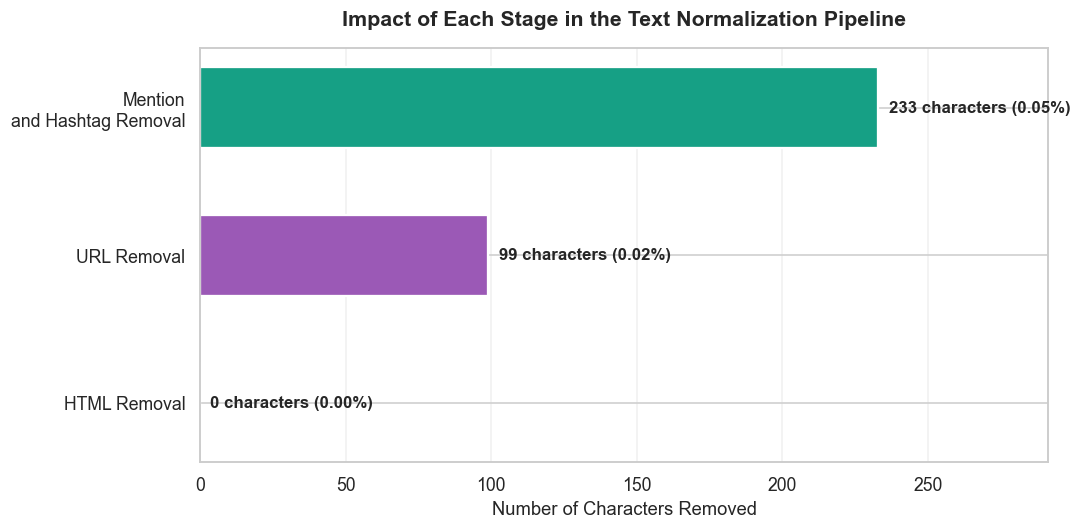

In [52]:
# Plot a horizontal bar chart for the three primary removal stages
fig, ax = plt.subplots(figsize=(10, 5))

steps = ["HTML Removal", "URL Removal", "Mention\nand Hashtag Removal"]
removed_counts = [total_html, total_url, total_mention]
colors_steps = ["#e67e22", "#9b59b6", "#16a085"]

bars = ax.barh(steps, removed_counts, color=colors_steps,
               edgecolor="white", linewidth=1.5, height=0.55)

for bar, val in zip(bars, removed_counts):
    pct = val / total_original * 100 if total_original > 0 else 0
    ax.text(bar.get_width() + max(removed_counts) * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f"{val:,} characters ({pct:.2f}%)",
            va="center", fontsize=11, fontweight="bold")

ax.set_xlabel("Number of Characters Removed", fontsize=12)
ax.set_title("Impact of Each Stage in the Text Normalization Pipeline",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlim(0, max(removed_counts) * 1.25 if max(removed_counts) > 0 else 1)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### 3.4. Calculate auxiliary features for EDA

Để phục vụ phân tích sau, ta tính sẵn một loạt đặc trưng từ trường text gốc:

- **Số từ và số ký tự** — thước đo độ dài cơ bản.
- **Tỉ lệ emoji** — review thật cũng có emoji nhưng không quá nhiều.
- **Tỉ lệ ký tự đặc biệt** — phát hiện spam ký hiệu.
- **Tỉ lệ chữ in hoa** — phát hiện kiểu hét lên.
- **Tỉ lệ chữ số** — phát hiện chuỗi số lạ.
- **Type-Token Ratio (TTR)** — đo độ phong phú từ vựng, gợi ý từ đề bài.

In [53]:
# Compute fundamental textual features for each review
df["word_count"] = df["text"].apply(count_words)
df["char_count"] = df["text"].astype(str).str.len()
df["emoji_ratio"] = df["text"].apply(get_emoji_ratio)
df["special_char_ratio"] = df["text"].apply(get_special_char_ratio)
df["uppercase_ratio"] = df["text"].apply(get_uppercase_ratio)
df["digit_ratio"] = df["text"].apply(get_digit_ratio)
df["ttr"] = df["text"].apply(get_type_token_ratio)

# Display descriptive statistics for the extracted features
feature_cols = ["word_count", "char_count", "emoji_ratio", "special_char_ratio",
                "uppercase_ratio", "digit_ratio", "ttr"]
desc = df[feature_cols].describe().round(3)
display(desc.style.background_gradient(cmap="Blues", axis=1))

,word_count,char_count,emoji_ratio,special_char_ratio,uppercase_ratio,digit_ratio,ttr
count,6193.000000,6193.000000,6193.000000,6193.000000,6193.000000,6193.000000,6193.000000
mean,17.930000,81.707000,0.003000,0.031000,0.027000,0.007000,0.944000
std,16.817000,76.064000,0.038000,0.054000,0.047000,0.029000,0.114000
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,24.000000,0.000000,0.000000,0.000000,0.000000,0.926000
50%,16.000000,72.000000,0.000000,0.028000,0.027000,0.000000,1.000000
75%,26.000000,117.000000,0.000000,0.043000,0.038000,0.000000,1.000000
max,219.000000,994.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 4. Apply spam filters.

Đây là bước quan trọng nhất của notebook. Toàn bộ logic phát hiện đã được đóng gói trong hàm `detect_spam` của module `spam_filter`.

### Hàm này làm gì?

1. **Chấm 16 luật ở mức từng đánh giá riêng lẻ** — mỗi đánh giá được kiểm tra qua từng luật để xác định có dấu hiệu spam nào không.
2. **Tính cosine similarity trên TF-IDF** để tìm các cụm đánh giá trùng lặp (seeding hàng loạt).
3. **Trả về dataframe** được bổ sung đúng một cột `is_spam` (0 nếu sạch, 1 nếu nghi spam).

### Tại sao chọn ngưỡng 0.85 cho cosine similarity?

Đây là ngưỡng cân bằng giữa precision và recall:
- Ngưỡng quá cao (0.95) sẽ bỏ sót nhiều seeding chỉ đổi vài từ.
- Ngưỡng quá thấp (0.70) sẽ bắt nhầm các review thật cùng chủ đề.
- Ngưỡng 0.85 thường được dùng trong các nghiên cứu về phát hiện văn bản trùng lặp.

In [54]:
# Apply the spam detection filter to the fully preprocessed dataset
df_flagged = detect_spam(df, dup_threshold=0.85)
print()
print("Spam labeling has been successfully completed for the entire dataframe")

[spam_filter] Đang chấm các luật ở mức từng review...
[spam_filter] Đang tính cosine similarity để tìm review trùng lặp...
[spam_filter] Hoàn tất. Tổng review: 6,193, Nghi spam: 3,202

Spam labeling has been successfully completed for the entire dataframe


### 4.1. Quick results check

Xem một vài dòng để xác nhận cột `is_spam` đã được thêm đúng cách và có giá trị 0 hoặc 1.

In [55]:
display(df_flagged[["text", "rating", "is_spam"]].head(10))

,text,rating,is_spam
0,Đọc quá trời hay luôn á 5⭐️ Kh có ảnh nên lấy đại,5,0
1,"Hay nha, sẽ ủng hộ dài dài, đóng gói oki",5,0
2,"Nội dung gần gũi, sách đẹp, giao hàng nhanh, đ...",5,0
3,"Date xa , tui rất thích .Cả 3 loại dòng LipIce...",5,0
4,Điện thoại đag bị hư k up ảnh sản phẩm đc 🤭 nh...,5,0
5,rất thích son nầy dưỡng môi không bị khô,5,0
6,"Sản phẩm dùng được, nhưng giáo hàng chậm 4 ngày",4,0
7,Duong am moi hieu qua Toi mua rat nhieu lan vi...,5,0
8,"Mềm môi, dưỡng ẩm tốt, màu sáng nhẹ, ưa nhìn",5,0
9,"Dưỡng ẩm hiệu quả, màu tự nhiên",5,0


## 5. Exploratory Data Analysis (EDA) for Spam Data

Phần này phân tích chi tiết các đặc điểm của những đánh giá đã bị gắn cờ là spam, từ đó rút ra hiểu biết về hành vi seeding trên các sàn thương mại điện tử Việt Nam.

EDA được tổ chức theo cấu trúc của báo cáo dữ liệu:

- **5.1.** Thống kê mô tả tổng quan
- **5.2.** Phân tích phân bố nhãn (sạch / spam)
- **5.3.** Chi tiết theo từng loại luật
- **5.4.** Phân tích phân bố rating theo nhóm
- **5.5.** Mối quan hệ giữa độ dài văn bản và spam (kiểm định Mann-Whitney U)
- **5.6.** Top từ vựng và Word Cloud
- **5.7.** Type-Token Ratio (TTR) so sánh nhóm
- **5.8.** Phân phối Zipf của tần suất từ
- **5.9.** Vector hóa TF-IDF và t-SNE 2D với Silhouette Score
- **5.10.** Heatmap tương quan giữa các đặc trưng
- **5.11.** Phát hiện ngoại lệ và các mẫu điển hình

### 5.1. Overview of Spam and Clean Page Rates

Câu hỏi đầu tiên: trong toàn bộ đánh giá thu thập được, có bao nhiêu phần trăm là rác?

In [56]:
# Summarize key statistical indicators
stats = summarize_spam(df_flagged)

print(f"Total number of reviews   : {stats['total_reviews']:,}")
print(f"Legitimate reviews        : {stats['clean_count']:,} ({stats['clean_pct']}%)")
print(f"Potential spam reviews    : {stats['spam_count']:,} ({stats['spam_pct']}%)")

Total number of reviews   : 6,193
Legitimate reviews        : 2,991 (48.3%)
Potential spam reviews    : 3,202 (51.7%)


#### Donut chart: Clean review and spam review ratio

Biểu đồ donut (pie chart có lỗ giữa) cho cảm giác hiện đại hơn pie chart truyền thống và dễ đọc hơn khi có nhãn dài.

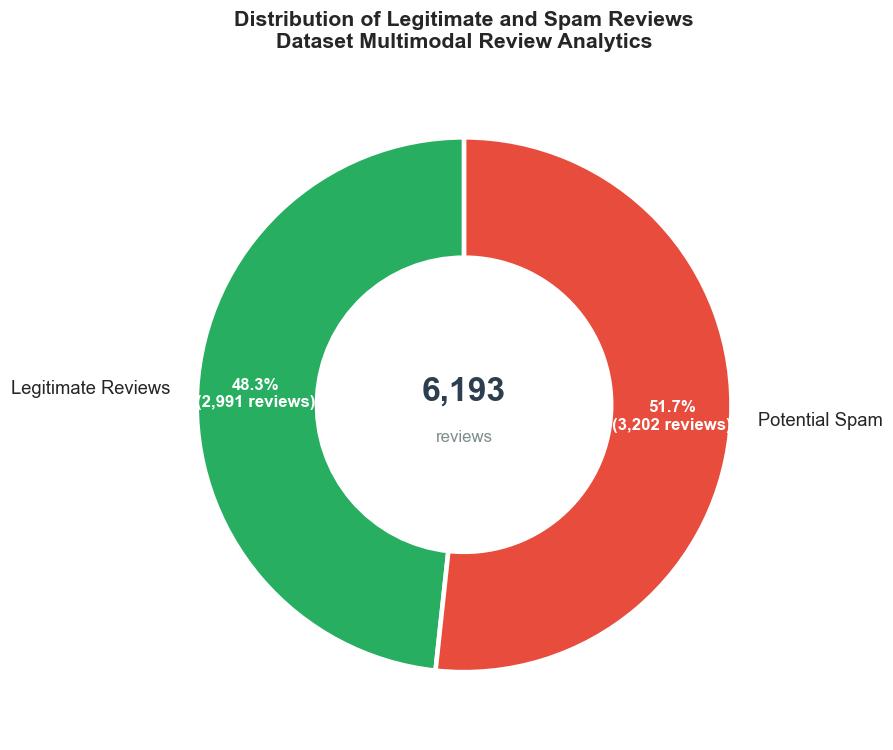

In [57]:
# Plot a donut chart illustrating the proportion of legitimate and spam reviews
fig, ax = plt.subplots(figsize=(9, 7))

labels = ["Legitimate Reviews", "Potential Spam"]
values = [stats["clean_count"], stats["spam_count"]]
colors = [COLOR_CLEAN, COLOR_SPAM]

wedges, texts, autotexts = ax.pie(
    values, labels=labels, colors=colors,
    autopct=lambda p: f"{p:.1f}%\n({int(round(p/100.*sum(values))):,} reviews)",
    startangle=90,
    textprops={"fontsize": 12},
    wedgeprops={"edgecolor": "white", "linewidth": 3, "width": 0.45},
    pctdistance=0.78,
)
for t in autotexts:
    t.set_fontweight("bold")
    t.set_color("white")
    t.set_fontsize(11)

# Add a centered annotation within the donut chart for visual emphasis
ax.text(0, 0.05, f"{stats['total_reviews']:,}",
        ha="center", va="center", fontsize=22, fontweight="bold", color="#2c3e50")
ax.text(0, -0.12, "reviews", ha="center", va="center", fontsize=11, color="#7f8c8d")

ax.set_title(f"Distribution of Legitimate and Spam Reviews\nDataset Multimodal Review Analytics",
             fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

### 5.2. Details of detected spam types

Một đánh giá có thể bị bắt bởi nhiều luật cùng lúc. Bảng và biểu đồ dưới đây cho thấy mỗi luật phát hiện được bao nhiêu trường hợp.

In [58]:
# Extract detailed statistics for each detection rule category
breakdown = stats["breakdown"]
df_breakdown = pd.DataFrame([
    {"Rule Category": k, "Count": v["count"], "Percentage (%)": v["pct"]}
    for k, v in breakdown.items()
]).sort_values("Count", ascending=False).reset_index(drop=True)

display(df_breakdown.style.bar(
    subset=["Count"], color=COLOR_SPAM, vmin=0
).background_gradient(subset=["Percentage (%)"], cmap="Reds", vmin=0))

,Rule Category,Count,Percentage (%)
0,Trùng lặp (seeding),1934,31.230000
1,5 sao kèm text rác,1072,17.310000
2,Quá ngắn (<3 từ),993,16.030000
3,Mẫu generic / template,491,7.930000
4,Spam bàn phím,180,2.910000
5,Mâu thuẫn rating - nội dung,155,2.500000
6,Bình luận nhận xu,49,0.790000
7,Chỉ số và dấu câu,14,0.230000
8,Chỉ toàn emoji,12,0.190000
9,Mã giảm giá rác,12,0.190000


#### Chart: Number of reviews seized by each law

Biểu đồ thanh ngang cho phép đọc tên luật dễ hơn (so với cột dọc) và sắp xếp theo thứ tự giảm dần để thấy ngay luật nào hoạt động mạnh nhất.

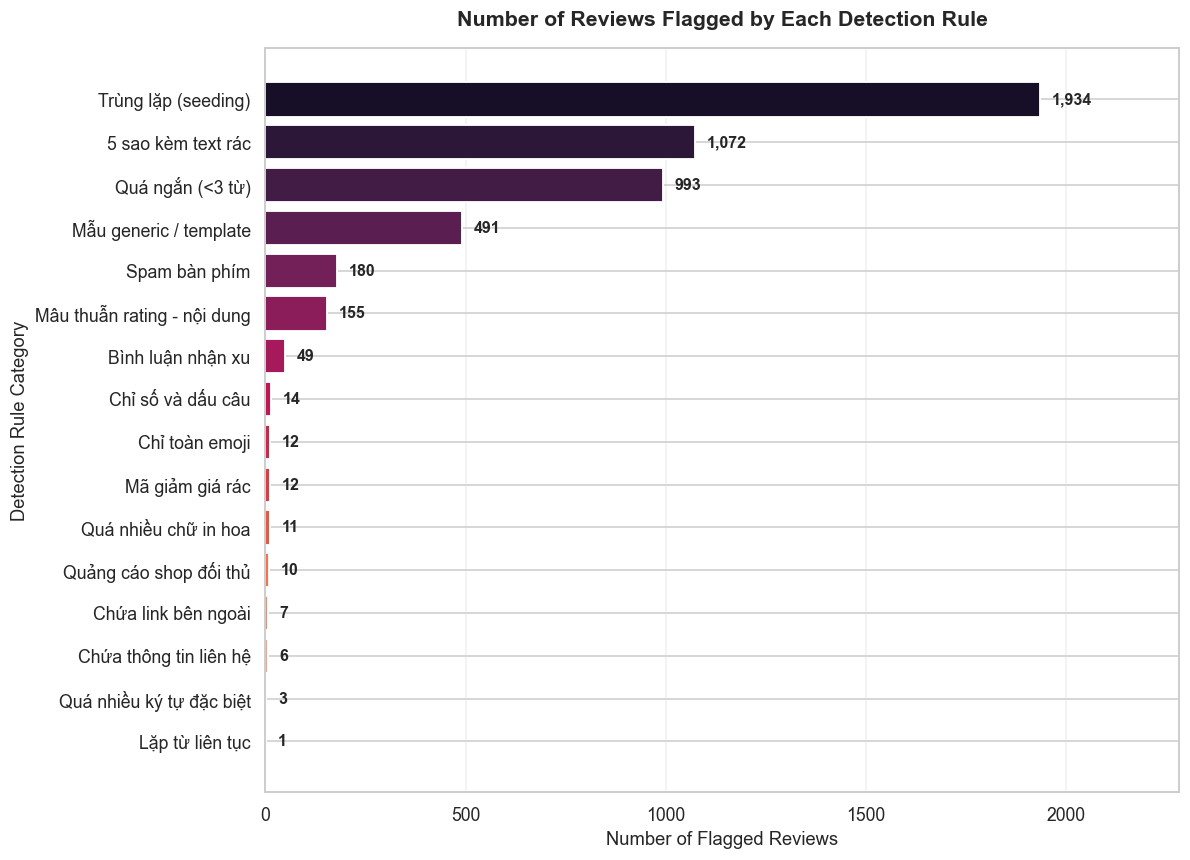

In [59]:
# Plot a horizontal bar chart to improve readability of spam category labels
fig, ax = plt.subplots(figsize=(11, 8))

data_plot = df_breakdown[df_breakdown["Count"] > 0].sort_values("Count", ascending=True)
n_bars = len(data_plot)
palette = sns.color_palette("rocket_r", n_colors=n_bars)

bars = ax.barh(data_plot["Rule Category"], data_plot["Count"],
               color=palette, edgecolor="white", linewidth=1.2)

max_val = data_plot["Count"].max()
for bar, count in zip(bars, data_plot["Count"]):
    ax.text(bar.get_width() + max_val * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f"{count:,}",
            va="center", fontsize=10.5, fontweight="bold")

ax.set_xlabel("Number of Flagged Reviews", fontsize=12)
ax.set_ylabel("Detection Rule Category", fontsize=12)
ax.set_title("Number of Reviews Flagged by Each Detection Rule",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlim(0, max_val * 1.18)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### 5.3. Distribution of spam and clean review ratings

Câu hỏi: liệu spam có tập trung ở rating cao không? Lý thuyết là seeding thường để 5 sao để đẩy điểm sản phẩm lên, còn review thật phân bố đều hơn.

In [60]:
# Compute the rating distribution for legitimate and spam review groups
rating_dist = (
    df_flagged.groupby(["rating", "is_spam"])
    .size()
    .unstack(fill_value=0)
)
rating_dist.columns = ["Legitimate" if c == 0 else "Spam" for c in rating_dist.columns]

# Compute the spam proportion within each rating category
rating_dist["Total"] = rating_dist.sum(axis=1)
rating_dist["Spam Percentage (%)"] = (
    rating_dist["Spam"] / rating_dist["Total"] * 100
).round(2)

display(rating_dist.style.bar(
    subset=["Spam Percentage (%)"], color=COLOR_SPAM, vmin=0, vmax=100
))

,Legitimate,Spam,Total,Spam Percentage (%)
rating,,,,
1,109,8,117,6.840000
2,43,5,48,10.420000
3,75,8,83,9.640000
4,132,97,229,42.360000
5,2632,3084,5716,53.950000


#### Chart: Comparison of rating distribution between the two groups

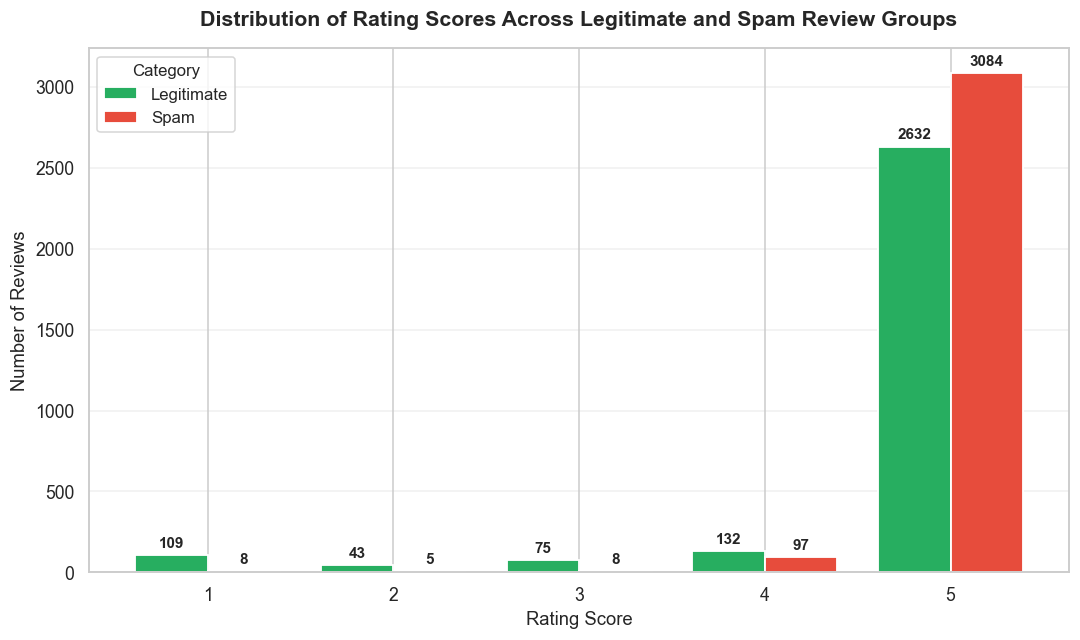

In [61]:
# Plot a grouped bar chart comparing review counts across rating levels
fig, ax = plt.subplots(figsize=(10, 6))

rating_plot = rating_dist[["Legitimate", "Spam"]]
rating_plot.plot(
    kind="bar", ax=ax,
    color=[COLOR_CLEAN, COLOR_SPAM],
    edgecolor="white", linewidth=1.2, width=0.78,
)

for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding=3, fmt="%d", fontweight="bold")

ax.set_xlabel("Rating Score", fontsize=12)
ax.set_ylabel("Number of Reviews", fontsize=12)
ax.set_title("Distribution of Rating Scores Across Legitimate and Spam Review Groups",
             fontsize=14, fontweight="bold", pad=15)
ax.legend(title="Category", title_fontsize=11, fontsize=11, loc="upper left")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#### Chart: Spam Rate by Rating Level

Biểu đồ này cho thấy rõ hơn rằng tỉ lệ spam thay đổi như thế nào khi rating tăng / giảm.

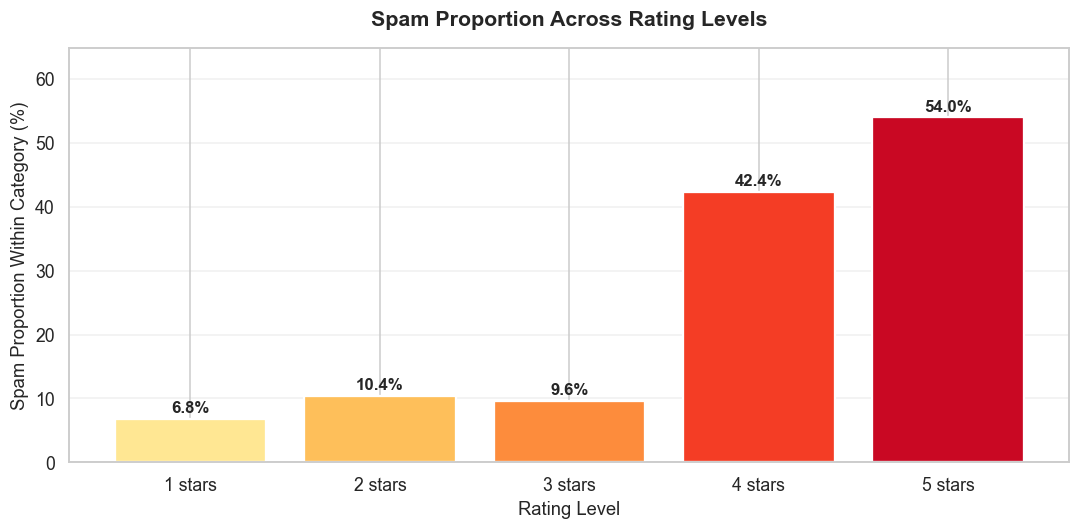

In [62]:
# Plot a bar chart illustrating the spam proportion across rating levels
fig, ax = plt.subplots(figsize=(10, 5))

rating_data = rating_dist.reset_index()
palette_rating = sns.color_palette("YlOrRd", n_colors=len(rating_data))

bars = ax.bar(
    rating_data["rating"].astype(str) + " stars",
    rating_data["Spam Percentage (%)"],
    color=palette_rating, edgecolor="white", linewidth=1.5,
)
for bar, val in zip(bars, rating_data["Spam Percentage (%)"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f"{val:.1f}%",
            ha="center", fontsize=11, fontweight="bold")

ax.set_xlabel("Rating Level", fontsize=12)
ax.set_ylabel("Spam Proportion Within Category (%)", fontsize=12)
ax.set_title("Spam Proportion Across Rating Levels",
             fontsize=14, fontweight="bold", pad=15)
ax.set_ylim(0, max(rating_data["Spam Percentage (%)"].max() * 1.2, 10))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 5.4. Analyzing text length by group

#### Tại sao quan tâm độ dài?

Trực giác cho thấy đánh giá quá ngắn dễ là spam (kiểu "ok", "tốt") còn đánh giá dài thường có giá trị thông tin hơn. Phần này kiểm chứng giả thuyết đó bằng cả thống kê mô tả và **kiểm định Mann-Whitney U** (theo gợi ý của đề bài) để xác định liệu hai phân phối độ dài có khác biệt đáng kể về mặt thống kê không.

Mann-Whitney U là kiểm định phi tham số (không cần giả định phân phối chuẩn) so sánh trung vị của hai mẫu độc lập, rất phù hợp với dữ liệu độ dài văn bản vốn lệch phải mạnh.

In [63]:
# Compute descriptive statistics of text length for the legitimate and spam groups
# Note: the df_flagged dataframe contains attrs with a detailed flag table
# attached by the spam_filter module. When using groupby().describe(), pandas may
# raise the error: "truth value of a DataFrame is ambiguous".
# Since .copy() also preserves attrs, we construct a completely new dataframe
# from dictionaries to fully detach all inherited attrs.
df_tmp = pd.DataFrame({
    "is_spam": df_flagged["is_spam"].values,
    "word_count": df_flagged["word_count"].values,
    "char_count": df_flagged["char_count"].values,
})

# Manually compute descriptive statistics instead of using describe()
# to ensure robustness and avoid the above issue
def compute_desc(group):
    return pd.Series({
        "count": len(group),
        "mean": group.mean(),
        "std": group.std(),
        "min": group.min(),
        "25%": group.quantile(0.25),
        "50% (median)": group.median(),
        "75%": group.quantile(0.75),
        "max": group.max(),
    })

desc_word = df_tmp.groupby("is_spam")["word_count"].apply(compute_desc).unstack().round(2)
desc_char = df_tmp.groupby("is_spam")["char_count"].apply(compute_desc).unstack().round(2)

# Rename index labels for better interpretability
desc_word.index = ["Legitimate", "Spam"]
desc_char.index = ["Legitimate", "Spam"]

print("Descriptive Statistics of Word Count by Group:")
display(desc_word)

print()
print("Descriptive Statistics of Character Count by Group:")
display(desc_char)

Descriptive Statistics of Word Count by Group:


,count,mean,std,min,25%,50% (median),75%,max
Legitimate,2991.0,18.44,14.29,3.0,8.0,15.0,25.0,174.0
Spam,3202.0,17.45,18.86,0.0,2.0,16.0,27.0,219.0



Descriptive Statistics of Character Count by Group:


,count,mean,std,min,25%,50% (median),75%,max
Legitimate,2991.0,82.28,64.16,7.0,35.0,68.0,111.0,723.0
Spam,3202.0,81.17,85.71,1.0,8.0,77.0,122.0,994.0


In [64]:
# Perform the Mann-Whitney U test on word count distributions
clean_words = df_flagged[df_flagged["is_spam"] == 0]["word_count"]
spam_words = df_flagged[df_flagged["is_spam"] == 1]["word_count"]

u_stat, p_value = scipy_stats.mannwhitneyu(
    clean_words, spam_words, alternative="two-sided"
)

print("Results of the Mann-Whitney U Test on Word Count:")
print(f"  U-statistic          : {u_stat:,.0f}")
print(f"  p-value              : {p_value:.6e}")
print(f"  Median (Legitimate)  : {clean_words.median():.0f} words")
print(f"  Median (Spam)        : {spam_words.median():.0f} words")
print()

if p_value < 0.001:
    print("  Conclusion: The two groups exhibit a highly statistically significant difference in text length (p < 0.001).")
elif p_value < 0.05:
    print("  Conclusion: The two groups exhibit a statistically significant difference in text length (p < 0.05).")
else:
    print("  Conclusion: There is insufficient evidence to conclude a statistically significant difference in text length between the two groups.")

Results of the Mann-Whitney U Test on Word Count:
  U-statistic          : 5,408,694
  p-value              : 1.068735e-18
  Median (Legitimate)  : 15 words
  Median (Spam)        : 16 words

  Conclusion: The two groups exhibit a highly statistically significant difference in text length (p < 0.001).


#### Chart: Distribution of text length by group

Dùng box plot kết hợp violin plot để vừa thấy được trung vị, tứ phân vị, vừa thấy được mật độ phân bố.

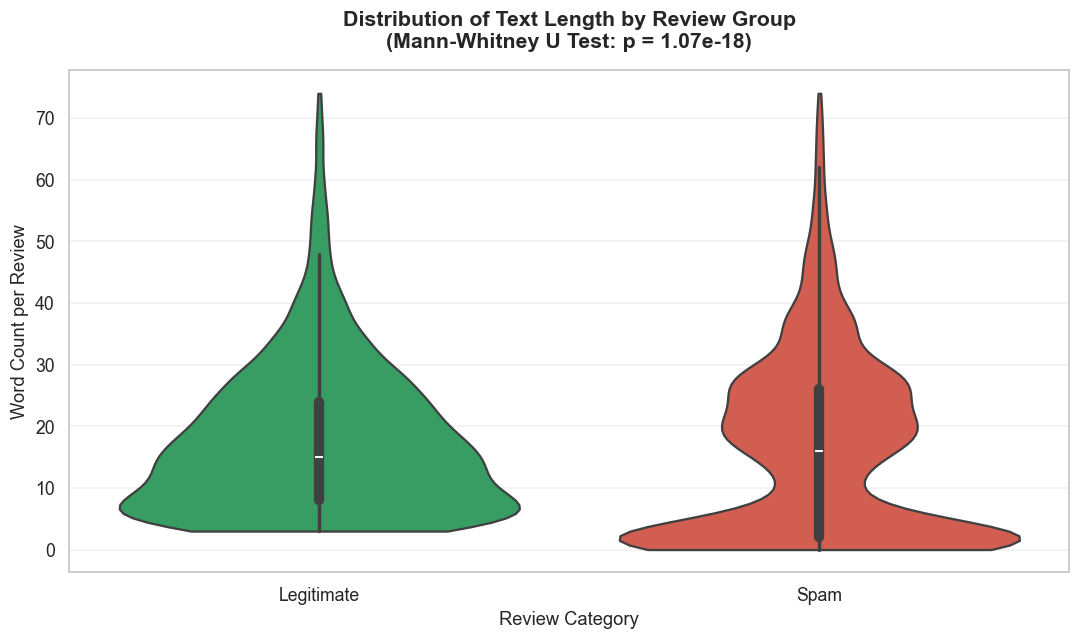

In [65]:
# Filter out extreme values (top 1%) to improve visualization clarity
upper_limit = df_flagged["word_count"].quantile(0.99)
df_plot = df_flagged[df_flagged["word_count"] <= upper_limit].copy()
df_plot["Group"] = df_plot["is_spam"].map({0: "Legitimate", 1: "Spam"})

fig, ax = plt.subplots(figsize=(10, 6))

sns.violinplot(
    data=df_plot, x="Group", y="word_count", ax=ax,
    palette=[COLOR_CLEAN, COLOR_SPAM],
    inner="box", linewidth=1.5, cut=0,
)

ax.set_xlabel("Review Category", fontsize=12)
ax.set_ylabel("Word Count per Review", fontsize=12)
ax.set_title(f"Distribution of Text Length by Review Group\n"
             f"(Mann-Whitney U Test: p = {p_value:.2e})",
             fontsize=14, fontweight="bold", pad=15)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 5.5. Spam rate by text length range

Câu hỏi cụ thể hơn: review càng ngắn thì tỉ lệ spam càng cao đúng không? Cắt độ dài thành nhiều dải để xem xu hướng.

In [66]:
# Partition word counts into logically defined length intervals
bins = [0, 3, 7, 15, 30, 60, 100, 100000]
bin_labels = ["1-3", "4-7", "8-15", "16-30", "31-60", "61-100", ">100"]

df_flagged["length_bin"] = pd.cut(
    df_flagged["word_count"], bins=bins, labels=bin_labels, right=True
)

length_table = (
    df_flagged.groupby("length_bin", observed=True)
    .agg(total=("is_spam", "size"), spam_count=("is_spam", "sum"))
)

length_table["spam_pct"] = (
    length_table["spam_count"] / length_table["total"] * 100
).round(2)

length_table.columns = ["Total Reviews", "Spam Count", "Spam Percentage (%)"]

display(length_table.style.bar(
    subset=["Spam Percentage (%)"], color=COLOR_SPAM, vmin=0, vmax=100
))

,Total Reviews,Spam Count,Spam Percentage (%)
length_bin,,,
1-3,1235,1104,89.390000
4-7,742,197,26.550000
8-15,1088,249,22.890000
16-30,2189,1141,52.120000
31-60,810,434,53.580000
61-100,101,54,53.470000
>100,21,16,76.190000


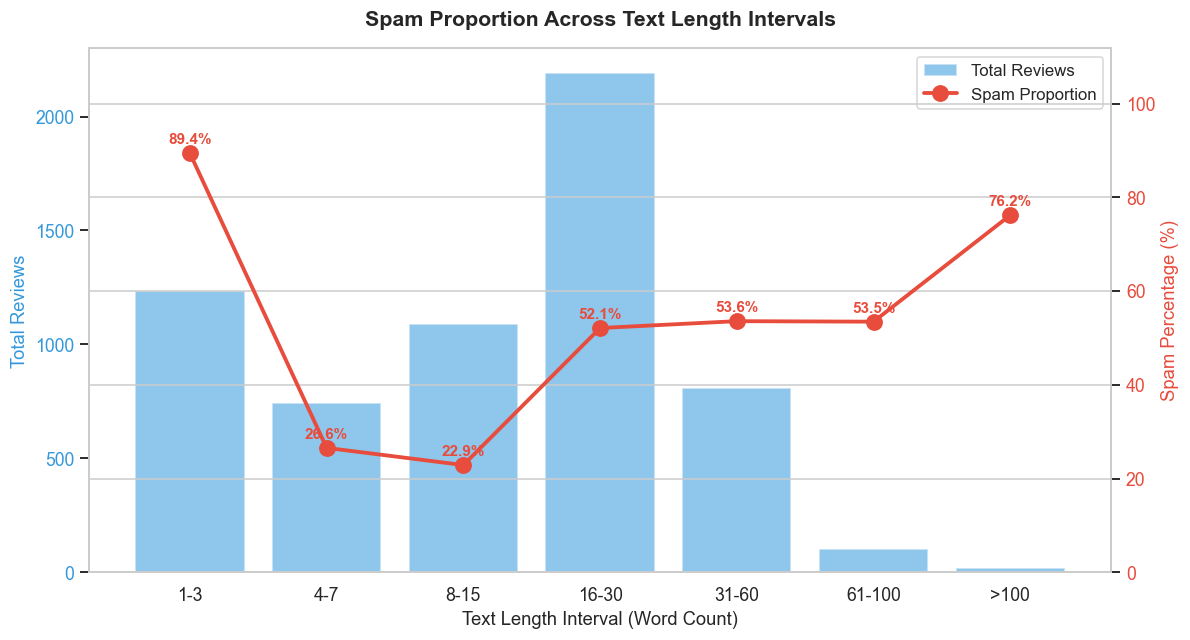

In [67]:
# Plot a combined chart: bars represent review counts, while the line indicates spam proportion
fig, ax1 = plt.subplots(figsize=(11, 6))

x_pos = np.arange(len(length_table))
ax1.bar(x_pos, length_table["Total Reviews"],
        color=COLOR_NEUTRAL, alpha=0.55, edgecolor="white", linewidth=1.2,
        label="Total Reviews")
ax1.set_xlabel("Text Length Interval (Word Count)", fontsize=12)
ax1.set_ylabel("Total Reviews", fontsize=12, color=COLOR_NEUTRAL)
ax1.tick_params(axis="y", labelcolor=COLOR_NEUTRAL)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(length_table.index)

# Secondary y-axis for spam proportion
ax2 = ax1.twinx()
ax2.plot(x_pos, length_table["Spam Percentage (%)"],
         color=COLOR_SPAM, marker="o", markersize=10, linewidth=2.5,
         label="Spam Proportion")

for i, val in enumerate(length_table["Spam Percentage (%)"]):
    ax2.text(i, val + 2, f"{val:.1f}%", ha="center",
             fontsize=10, fontweight="bold", color=COLOR_SPAM)

ax2.set_ylabel("Spam Percentage (%)", fontsize=12, color=COLOR_SPAM)
ax2.tick_params(axis="y", labelcolor=COLOR_SPAM)
ax2.set_ylim(0, max(length_table["Spam Percentage (%)"].max() * 1.25, 10))

plt.title("Spam Proportion Across Text Length Intervals",
          fontsize=14, fontweight="bold", pad=15)

# Merge legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=11)

ax1.grid(False)
plt.tight_layout()
plt.show()

### 5.6. Top Vocabulary and Word Cloud by Group
Theo gợi ý của đề bài, ta vẽ word cloud và bảng top-50 từ phổ biến nhất cho từng lớp. Việc này giúp hiểu được spam và review thật khác nhau ở mặt từ vựng như thế nào.

In [68]:
# Tokenization function for basic word segmentation and frequency counting
import re as _re

def tokenize_simple(text):
    """Basic tokenization: lowercase conversion, special character removal, and whitespace splitting."""
    text = remove_emojis(normalize_text(text))
    text = _re.sub(r"[^\w\s]", " ", text, flags=_re.UNICODE)
    return [w for w in text.split() if len(w) >= 2]

# Compute word frequency distributions for each review group
print("Computing token frequency distributions for legitimate and spam review groups...")

clean_tokens = []
for t in df_flagged[df_flagged["is_spam"] == 0]["text"]:
    clean_tokens.extend(tokenize_simple(t))

spam_tokens = []
for t in df_flagged[df_flagged["is_spam"] == 1]["text"]:
    spam_tokens.extend(tokenize_simple(t))

clean_freq = Counter(clean_tokens)
spam_freq = Counter(spam_tokens)

print(f"Total tokens in the legitimate group: {len(clean_tokens):,}")
print(f"Total tokens in the spam group: {len(spam_tokens):,}")  

Computing token frequency distributions for legitimate and spam review groups...
Total tokens in the legitimate group: 54,181
Total tokens in the spam group: 55,893


#### Top 20 Most Common Words in Clean and Spam Categories

In [69]:
# Create top-20 frequency tables for each group for comparative analysis
top_n = 20
top_clean = pd.DataFrame(clean_freq.most_common(top_n),
                         columns=["Word (Legitimate)", "Frequency (Legitimate)"])
top_spam = pd.DataFrame(spam_freq.most_common(top_n),
                        columns=["Word (Spam)", "Frequency (Spam)"])
top_combined = pd.concat([top_clean, top_spam], axis=1)
display(top_combined)

,Word (Legitimate),Frequency (Legitimate),Word (Spam),Frequency (Spam)
0,hàng,1238,cho,1519
1,và,979,và,1312
2,giao,916,tốt,1081
3,cho,731,thức,821
4,nhanh,701,công,819
5,chất,675,của,749
6,rất,663,bé,735
7,giá,662,sữa,721
8,mua,598,tôi,699
9,shop,509,rất,687


#### Word Cloud for Clean Teams

The wordcloud library is not installed. Run: pip install wordcloud


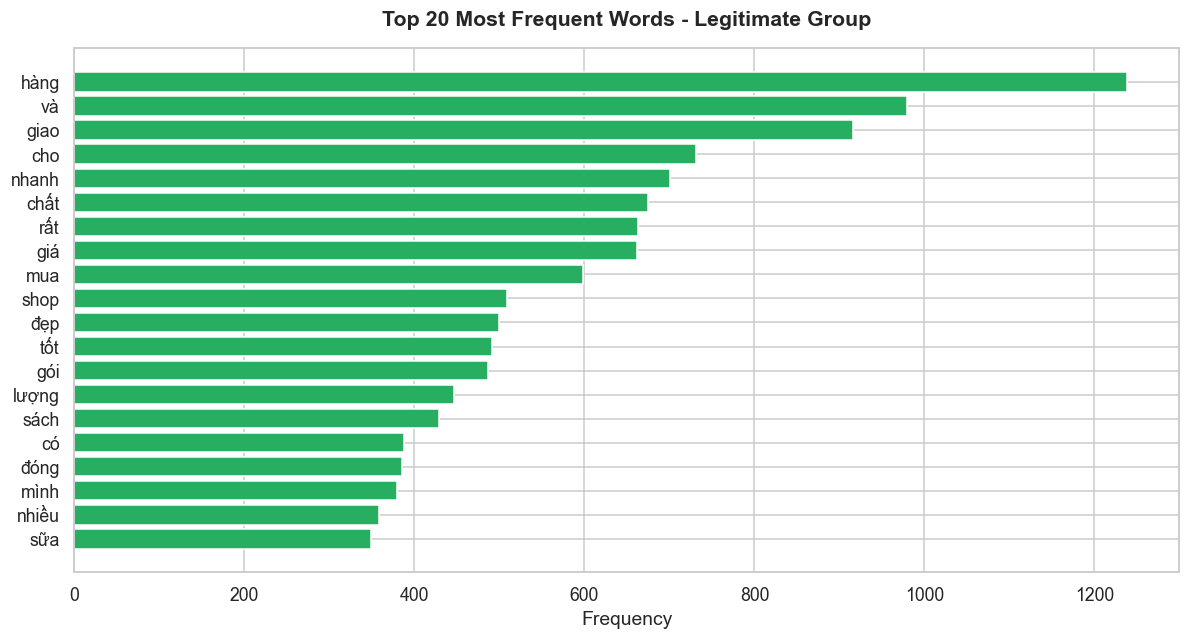

In [70]:
# Generate a word cloud visualization for the legitimate review group
try:
    from wordcloud import WordCloud
    
    wc_clean = WordCloud(
        width=900, height=500,
        background_color="white",
        colormap="Greens",
        max_words=100,
        relative_scaling=0.5,
        prefer_horizontal=0.9,
    ).generate_from_frequencies(clean_freq)

    fig, ax = plt.subplots(figsize=(11, 6))
    ax.imshow(wc_clean, interpolation="bilinear")
    ax.axis("off")
    ax.set_title("Word Cloud - Legitimate Review Group",
                 fontsize=14, fontweight="bold", pad=15, color=COLOR_CLEAN)
    plt.tight_layout()
    plt.show()

except ImportError:
    print("The wordcloud library is not installed. Run: pip install wordcloud")

    # Fallback: plot a top-20 frequency bar chart instead
    fig, ax = plt.subplots(figsize=(11, 6))
    top20_clean = clean_freq.most_common(20)
    words, freqs = zip(*top20_clean)

    ax.barh(words[::-1], freqs[::-1], color=COLOR_CLEAN, edgecolor="white")
    ax.set_title("Top 20 Most Frequent Words - Legitimate Group",
                 fontsize=14, fontweight="bold", pad=15)
    ax.set_xlabel("Frequency")

    plt.tight_layout()
    plt.show()

#### Word Cloud cho nhóm spam

The wordcloud library is not installed. Run: pip install wordcloud


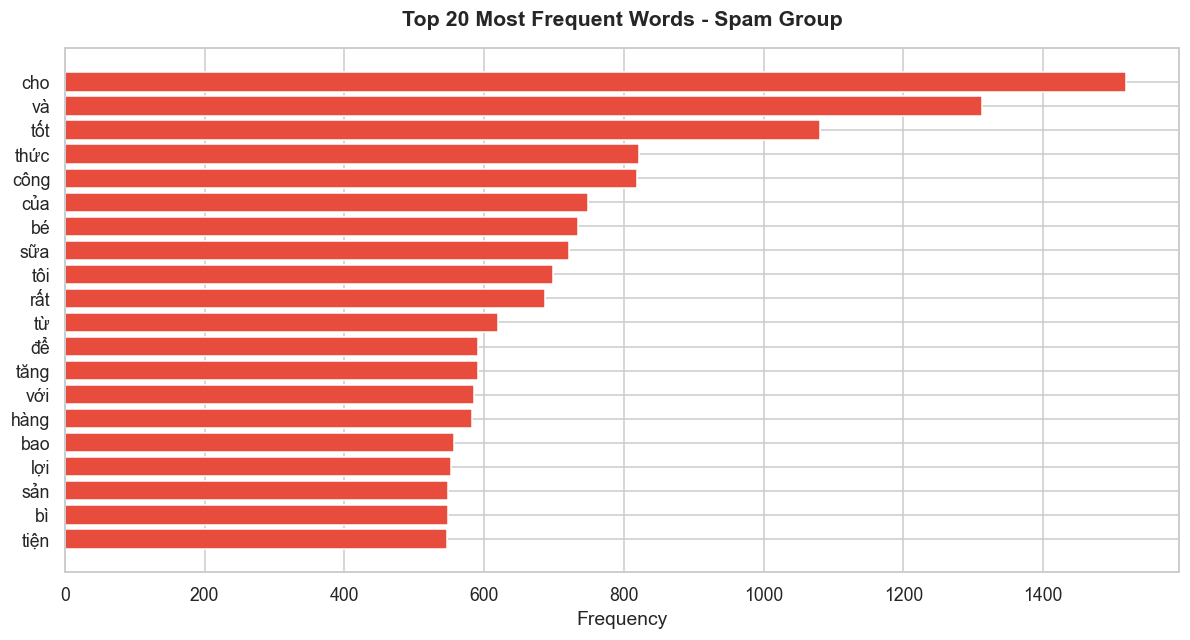

In [71]:
# Generate a word cloud visualization for the spam review group
try:
    from wordcloud import WordCloud
    
    wc_spam = WordCloud(
        width=900, height=500,
        background_color="white",
        colormap="Reds",
        max_words=100,
        relative_scaling=0.5,
        prefer_horizontal=0.9,
    ).generate_from_frequencies(spam_freq)

    fig, ax = plt.subplots(figsize=(11, 6))
    ax.imshow(wc_spam, interpolation="bilinear")
    ax.axis("off")
    ax.set_title("Word Cloud - Spam Review Group",
                 fontsize=14, fontweight="bold", pad=15, color=COLOR_SPAM)
    plt.tight_layout()
    plt.show()

except ImportError:
    print("The wordcloud library is not installed. Run: pip install wordcloud")

    # Fallback: plot a top-20 frequency bar chart instead
    fig, ax = plt.subplots(figsize=(11, 6))
    top20_spam = spam_freq.most_common(20)
    words, freqs = zip(*top20_spam)

    ax.barh(words[::-1], freqs[::-1], color=COLOR_SPAM, edgecolor="white")
    ax.set_title("Top 20 Most Frequent Words - Spam Group",
                 fontsize=14, fontweight="bold", pad=15)
    ax.set_xlabel("Frequency")

    plt.tight_layout()
    plt.show()

### 5.7. Type-Token Ratio (TTR) assesses vocabulary richness.

Type-Token Ratio = số từ duy nhất / tổng số từ. Theo gợi ý của đề bài, đây là chỉ số đo độ phong phú từ vựng:

- **TTR cao** (gần 1.0): mỗi từ chỉ xuất hiện một lần → văn bản đa dạng từ vựng.
- **TTR thấp** (gần 0): nhiều từ bị lặp → văn bản nghèo nàn, có thể là spam.

Giả thuyết: nhóm spam có TTR thấp hơn nhóm sạch.

In [72]:
# Compare Type-Token Ratio (TTR) between the two review groups
# Construct a new dataframe from dictionaries to fully detach inherited attrs
df_tmp_ttr = pd.DataFrame({
    "is_spam": df_flagged["is_spam"].values,
    "ttr": df_flagged["ttr"].values,
})

ttr_stats = df_tmp_ttr.groupby("is_spam")["ttr"].apply(compute_desc).unstack().round(3)
ttr_stats.index = ["Legitimate", "Spam"]
display(ttr_stats)

,count,mean,std,min,25%,50% (median),75%,max
Legitimate,2991.0,0.949,0.087,0.056,0.917,1.0,1.0,1.0
Spam,3202.0,0.940,0.134,0.000,0.933,1.0,1.0,1.0


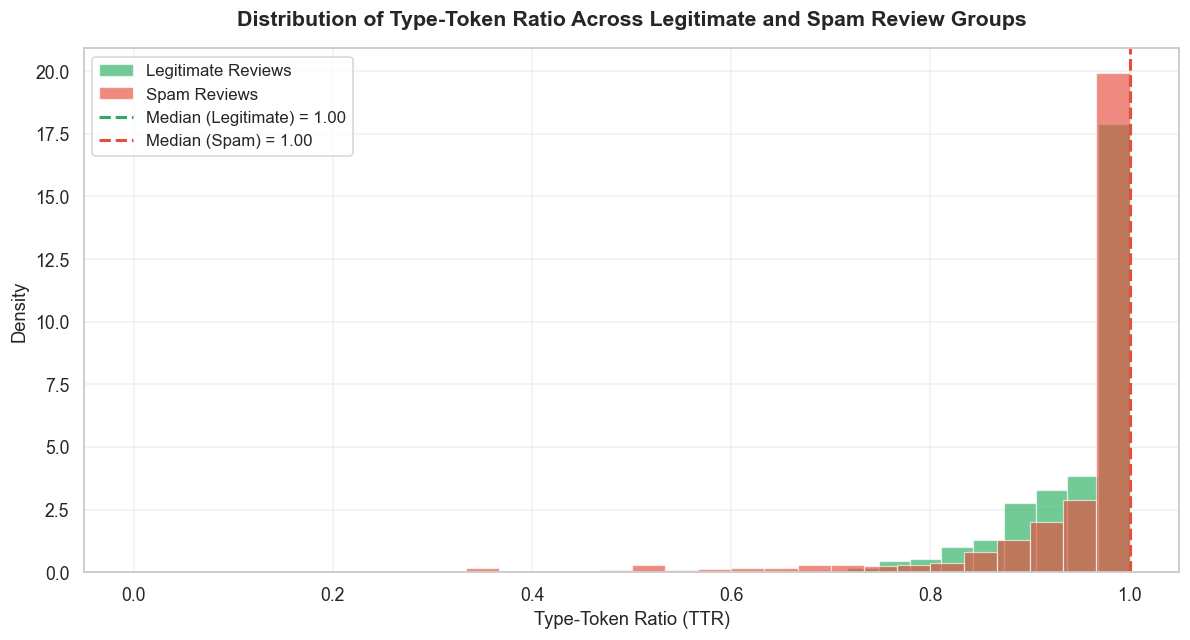

In [73]:
# Plot the Type-Token Ratio (TTR) distribution for the two review groups
fig, ax = plt.subplots(figsize=(11, 6))

ax.hist(df_flagged[df_flagged["is_spam"] == 0]["ttr"],
        bins=30, alpha=0.65, color=COLOR_CLEAN,
        label="Legitimate Reviews", edgecolor="white", linewidth=0.8, density=True)
ax.hist(df_flagged[df_flagged["is_spam"] == 1]["ttr"],
        bins=30, alpha=0.65, color=COLOR_SPAM,
        label="Spam Reviews", edgecolor="white", linewidth=0.8, density=True)

# Add the median reference line for each group
median_clean = df_flagged[df_flagged["is_spam"] == 0]["ttr"].median()
median_spam = df_flagged[df_flagged["is_spam"] == 1]["ttr"].median()

ax.axvline(median_clean, color=COLOR_CLEAN, linestyle="--", linewidth=2,
           label=f"Median (Legitimate) = {median_clean:.2f}")
ax.axvline(median_spam, color=COLOR_SPAM, linestyle="--", linewidth=2,
           label=f"Median (Spam) = {median_spam:.2f}")

ax.set_xlabel("Type-Token Ratio (TTR)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Distribution of Type-Token Ratio Across Legitimate and Spam Review Groups",
             fontsize=14, fontweight="bold", pad=15)
ax.legend(fontsize=11, loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.8. Zipf distribution of frequency distribution

Định luật Zipf nói rằng tần suất của từ thứ k phổ biến nhất tỉ lệ nghịch với k. Trên đồ thị log-log, mối quan hệ này gần như là một đường thẳng đi xuống.

#### Why should we care about Zipf for spam?

Văn bản tự nhiên của con người tuân theo định luật Zipf khá tốt. Nếu phân bố tần suất từ trong dữ liệu lệch khỏi Zipf đáng kể, đó là dấu hiệu của văn bản nhân tạo (sinh bởi máy hoặc copy-paste). Phần này so sánh phân phối Zipf của nhóm sạch và nhóm spam.

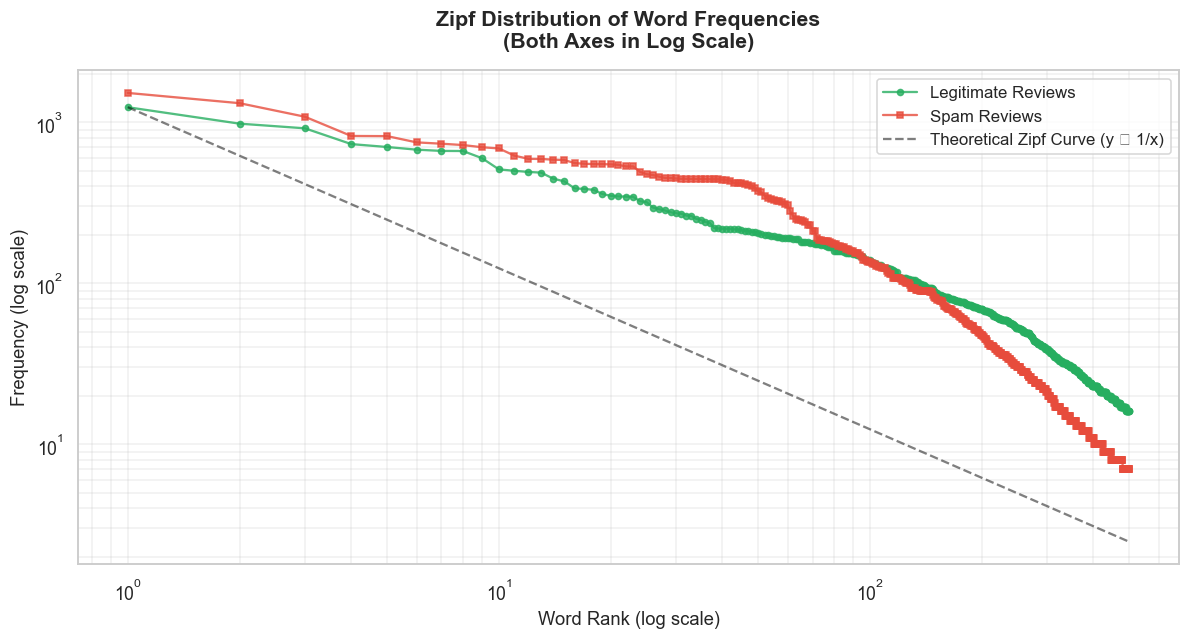

In [74]:
# Compute rank and frequency distributions for both review groups
def get_zipf_data(freq_counter, top_k=500):
    """Return (ranks, frequencies) sorted in descending order of frequency."""
    sorted_freq = sorted(freq_counter.values(), reverse=True)[:top_k]
    ranks = np.arange(1, len(sorted_freq) + 1)
    return ranks, np.array(sorted_freq)

ranks_clean, freqs_clean = get_zipf_data(clean_freq, top_k=500)
ranks_spam, freqs_spam = get_zipf_data(spam_freq, top_k=500)

# Plot the distributions on a log-log scale
fig, ax = plt.subplots(figsize=(11, 6))

ax.loglog(ranks_clean, freqs_clean, marker="o", markersize=4,
          linewidth=1.5, color=COLOR_CLEAN, alpha=0.8,
          label="Legitimate Reviews")
ax.loglog(ranks_spam, freqs_spam, marker="s", markersize=4,
          linewidth=1.5, color=COLOR_SPAM, alpha=0.8,
          label="Spam Reviews")

# Plot the theoretical Zipf curve y = c/x for comparison
if len(freqs_clean) > 0:
    c = freqs_clean[0]
    ax.loglog(ranks_clean, c / ranks_clean, "k--", alpha=0.5, linewidth=1.5,
              label="Theoretical Zipf Curve (y ∝ 1/x)")

ax.set_xlabel("Word Rank (log scale)", fontsize=12)
ax.set_ylabel("Frequency (log scale)", fontsize=12)
ax.set_title("Zipf Distribution of Word Frequencies\n(Both Axes in Log Scale)",
             fontsize=14, fontweight="bold", pad=15)
ax.legend(fontsize=11)
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

### 5.9. 2D TF-IDF and t-SNE vectorization

Theo gợi ý của đề bài, ta vector hóa văn bản bằng TF-IDF rồi giảm chiều xuống 2D bằng t-SNE để trực quan hóa khả năng tách biệt giữa hai lớp. Sau đó tính **silhouette score** để định lượng độ tách biệt.

#### Why TF-IDF + t-SNE?

- **TF-IDF** biến mỗi văn bản thành một vector trong không gian từ vựng cao chiều.
- **t-SNE** chiếu vector đó xuống 2D sao cho các điểm gần nhau trong không gian gốc vẫn gần nhau trong 2D.
- Nếu spam và sạch tách biệt tốt trong không gian TF-IDF, ta sẽ thấy hai cụm rõ ràng trên biểu đồ t-SNE.

In [75]:
# Perform TF-IDF vectorization using unigram and bigram features
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

# Subsample the dataset to improve computational efficiency
# (t-SNE becomes computationally expensive for datasets larger than 5,000 samples)
sample_size = min(3000, len(df_flagged))
df_sample = df_flagged.sample(n=sample_size, random_state=42).reset_index(drop=True)

print(f"Performing TF-IDF vectorization on {len(df_sample):,} samples...")

vectorizer = TfidfVectorizer(
    max_features=2000, ngram_range=(1, 2), min_df=2, max_df=0.95
)

tfidf_matrix = vectorizer.fit_transform(df_sample["text_clean"].fillna(""))

print(f"TF-IDF dimensionality: {tfidf_matrix.shape[1]:,}")
print(
    f"Sparsity: "
    f"{1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]):.4f}"
)

Performing TF-IDF vectorization on 3,000 samples...
TF-IDF dimensionality: 2,000
Sparsity: 0.9875


In [76]:
# Apply t-SNE for dimensionality reduction to a two-dimensional space
print("Running t-SNE for 2D dimensionality reduction (this may take approximately 30–60 seconds)...")

tsne = TSNE(
    n_components=2, perplexity=30, random_state=42,
    init="random", learning_rate=200, max_iter=1000,
)

tsne_coords = tsne.fit_transform(tfidf_matrix.toarray())
print("t-SNE computation completed")

# Compute the silhouette score to quantify group separability
labels_sample = df_sample["is_spam"].values
sil_score = silhouette_score(tsne_coords, labels_sample, metric="euclidean")

print(f"Silhouette score in the 2D t-SNE embedding space: {sil_score:.4f}")
print()

if sil_score > 0.3:
    print("The two groups exhibit relatively clear separation (silhouette > 0.3).")
elif sil_score > 0.1:
    print("The two groups exhibit moderate separability (0.1 < silhouette < 0.3).")
else:
    print("The two groups show substantial overlap in the TF-IDF feature space (silhouette < 0.1).")

Running t-SNE for 2D dimensionality reduction (this may take approximately 30–60 seconds)...
t-SNE computation completed
Silhouette score in the 2D t-SNE embedding space: 0.0561

The two groups show substantial overlap in the TF-IDF feature space (silhouette < 0.1).


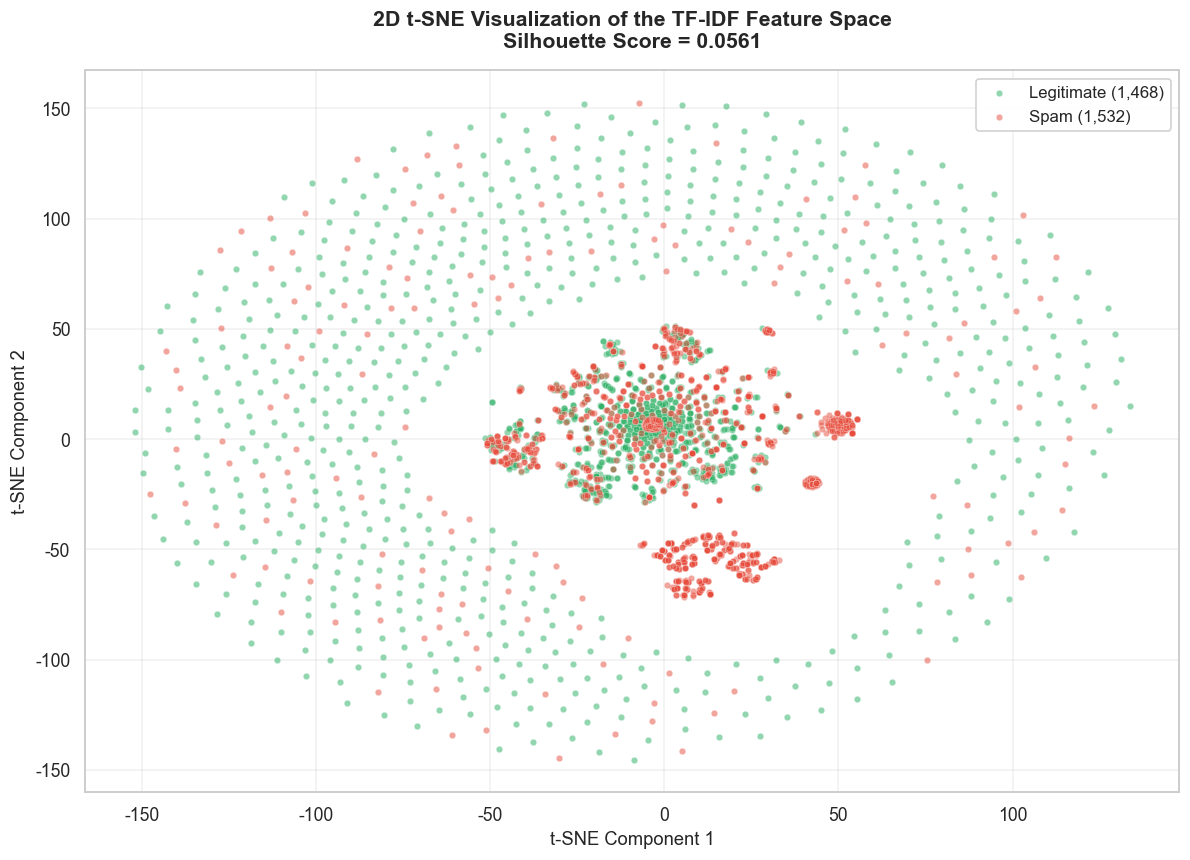

In [77]:
# Plot a 2D t-SNE scatter visualization colored by class label
fig, ax = plt.subplots(figsize=(11, 8))

mask_clean = labels_sample == 0
mask_spam = labels_sample == 1

ax.scatter(tsne_coords[mask_clean, 0], tsne_coords[mask_clean, 1],
           c=COLOR_CLEAN, alpha=0.5, s=18, edgecolors="white",
           linewidth=0.3, label=f"Legitimate ({mask_clean.sum():,})")

ax.scatter(tsne_coords[mask_spam, 0], tsne_coords[mask_spam, 1],
           c=COLOR_SPAM, alpha=0.5, s=18, edgecolors="white",
           linewidth=0.3, label=f"Spam ({mask_spam.sum():,})")

ax.set_xlabel("t-SNE Component 1", fontsize=12)
ax.set_ylabel("t-SNE Component 2", fontsize=12)
ax.set_title(f"2D t-SNE Visualization of the TF-IDF Feature Space\n"
             f"Silhouette Score = {sil_score:.4f}",
             fontsize=14, fontweight="bold", pad=15)

ax.legend(fontsize=11, loc="best", framealpha=0.95)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.10. Heatmap showing the correlation between features

Phân tích tương quan giữa các đặc trưng để phát hiện multicollinearity (theo yêu cầu của đề bài) và xem đặc trưng nào liên quan mạnh nhất đến nhãn `is_spam`.

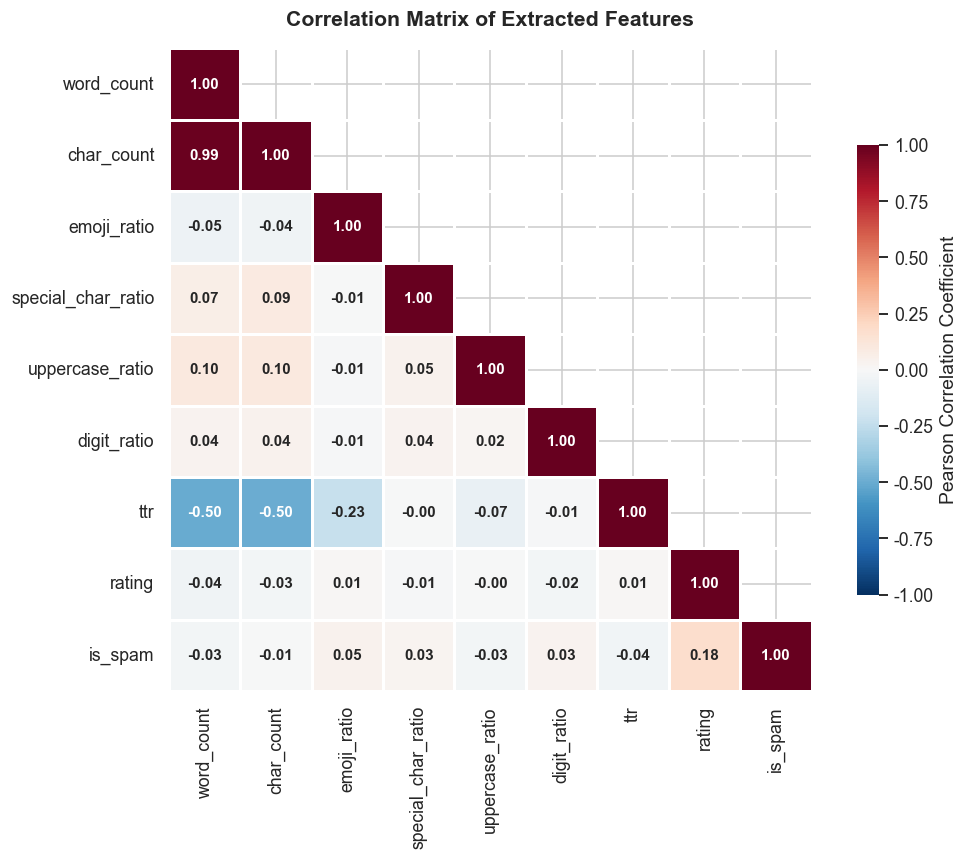

In [78]:
# Compute the Pearson correlation matrix among the extracted features
corr_cols = ["word_count", "char_count", "emoji_ratio", "special_char_ratio",
             "uppercase_ratio", "digit_ratio", "ttr", "rating", "is_spam"]
corr_matrix = df_flagged[corr_cols].corr()

# Plot the correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, square=True, linewidths=0.8, linecolor="white",
    cbar_kws={"shrink": 0.7, "label": "Pearson Correlation Coefficient"},
    annot_kws={"fontsize": 10, "fontweight": "bold"},
    mask=mask, ax=ax,
)

ax.set_title("Correlation Matrix of Extracted Features",
             fontsize=14, fontweight="bold", pad=15)

plt.tight_layout()
plt.show()

### 5.11. Detecting Outcomes and Typical Patterns

#### Phát hiện ngoại lệ độ dài bằng phương pháp IQR

Theo gợi ý của đề bài, ta dùng phương pháp Interquartile Range (IQR) để xác định ngoại lệ trong phân bố độ dài văn bản.

In [79]:
# Detect text-length outliers using the Interquartile Range (IQR) method
q1 = df_flagged["word_count"].quantile(0.25)
q3 = df_flagged["word_count"].quantile(0.75)
iqr = q3 - q1
upper_outlier = q3 + 1.5 * iqr
lower_outlier = max(0, q1 - 1.5 * iqr)

n_upper = (df_flagged["word_count"] > upper_outlier).sum()
n_lower = (df_flagged["word_count"] < lower_outlier).sum()

print(f"Q1 (25th percentile) : {q1:.0f} words")
print(f"Q3 (75th percentile) : {q3:.0f} words")
print(f"IQR                  : {iqr:.0f} words")
print(f"Upper outlier threshold : {upper_outlier:.0f} words")
print(f"Lower outlier threshold : {lower_outlier:.0f} words")
print()

print(f"Upper outliers (exceptionally long reviews)  : {n_upper:,} ({n_upper/len(df_flagged)*100:.2f}%)")
print(f"Lower outliers (exceptionally short reviews) : {n_lower:,} ({n_lower/len(df_flagged)*100:.2f}%)")

Q1 (25th percentile) : 5 words
Q3 (75th percentile) : 26 words
IQR                  : 21 words
Upper outlier threshold : 58 words
Lower outlier threshold : 0 words

Upper outliers (exceptionally long reviews)  : 141 (2.28%)
Lower outliers (exceptionally short reviews) : 0 (0.00%)


#### Typical review pattern from the SPAM team

Hiển thị một vài mẫu để xác minh trực quan rằng bộ luật hoạt động đúng.

In [80]:
# Randomly sample a subset of flagged spam reviews for inspection
df_spam = df_flagged[df_flagged["is_spam"] == 1]
n_show = min(8, len(df_spam))

if n_show > 0:
    samples = df_spam.sample(n=n_show, random_state=42)
    cols_show = ["text", "rating", "word_count"]
    cols_avail = [c for c in cols_show if c in samples.columns]

    samples_display = samples[cols_avail].copy()
    samples_display["text"] = samples_display["text"].astype(str).apply(
        lambda x: x[:120] + ("..." if len(x) > 120 else "")
    )

    display(samples_display.style.set_caption("Sample of Reviews Flagged as Spam").set_table_styles([
        {"selector": "caption", "props": [("color", COLOR_SPAM), ("font-size", "14px"), ("font-weight", "bold")]}
    ]))

else:
    print("No flagged spam samples are available for display")

,text,rating,word_count
4499,"Khăn giấy chất lượng cao, Hoàn hảo cho việc sử dụng hàng ngày,",5,13
790,Rất hài lòng.,5,3
2225,Ok,5,1
3476,thơm ngon,5,2
845,rất hay,5,2
3347,"Công thức sữa tốt nhất cho bé của tôi., Rất khuyến khích cho trẻ từ 12-24 tháng tuổi., Giúp hỗ trợ sự phát triển và tăng...",5,29
2986,Mình mua nhiều lần rồi nhưng không biết tại sao mấy lần sau này ko thấy dán team check mã code nữa,5,22
5393,tốt,5,1


#### Typical evaluation pattern from the CLEAN group

Đối chiếu để thấy sự khác biệt rõ ràng giữa hai nhóm.

In [81]:
# Randomly sample a subset of legitimate reviews for inspection
df_clean = df_flagged[df_flagged["is_spam"] == 0]
n_show = min(8, len(df_clean))

if n_show > 0:
    samples = df_clean.sample(n=n_show, random_state=42)
    cols_show = ["text", "rating", "word_count"]
    cols_avail = [c for c in cols_show if c in samples.columns]

    samples_display = samples[cols_avail].copy()
    samples_display["text"] = samples_display["text"].astype(str).apply(
        lambda x: x[:120] + ("..." if len(x) > 120 else "")
    )

    display(samples_display.style.set_caption("Sample of Legitimate Reviews").set_table_styles([
        {"selector": "caption", "props": [("color", COLOR_CLEAN), ("font-size", "14px"), ("font-weight", "bold")]}
    ]))

else:
    print("No legitimate review samples are available for display")

,text,rating,word_count
2383,Giao hàng mà hộp sữa bị cỡ này này rồi sao dám mua nữa,1,14
4365,"Hoàn hảo cho việc sử dụng hàng ngày, Thiết kế đẹp mắt, Thân thiện với môi trường và bền vững, Lâu dài và bền, Khăn giấy ...",5,29
1380,"trời ơi giao hàng gì mà lâu kinh khủng khiếp, hơn nửa tháng trời mua trả tiền trước rồi mà vậy ák, chắc mua lần đầu cũng...",1,87
5470,"Dáng quần dài theo xu hướng, Dáng quần dài theo xu hướng, Phù hợp với nhiều dịp khác nhau, Phù hợp với nhiều dịp khác nh...",5,44
516,"Sách đẹp nhưng đóng gói cẩu thả quá, shipper đi giao gặp trời mưa, ẩm, cong hết sách rồi.",3,19
2069,"Mùi vị thơm , bé sử dụng từ sơ sinh tới giờ đều hài lòng",5,15
5153,"Thiết kế thời trang và phong cách, Giá trị tuyệt vời so với giá,",5,14
4104,"khăn giấy sử dụng ổn . không có mùi , không cứng nữa . giao hàng đầy đủ ...nói chung ổn, đóng gói kỹ",5,24


## 6. Save results

Sau khi gán cờ và phân tích xong, ta lưu dataframe ra file CSV để các bước tiếp theo của dự án (huấn luyện mô hình ML, dashboard) có thể sử dụng.

### Important note regarding output file structure.

Theo yêu cầu, file CSV xuất ra **chỉ chứa các cột gốc của dữ liệu cộng thêm đúng một cột mới `is_spam`** (giá trị 0 hoặc 1). Các cột phụ tính toán trong notebook (như `word_count`, `text_clean`, `ttr`, `length_bin`) chỉ phục vụ phân tích nội bộ và không được lưu ra file.

In [82]:
# Determine the set of columns to export: original columns from df_raw plus the is_spam label
original_cols = [c for c in df_raw.columns if c in df_flagged.columns]
export_cols = original_cols + ["is_spam"]

df_export = df_flagged[export_cols].copy()

print(f"Columns to be exported to the CSV file: {list(df_export.columns)}")
print(f"Total number of rows: {len(df_export):,}")
print("Distribution of the is_spam label:")
print(df_export["is_spam"].value_counts().to_string())

Columns to be exported to the CSV file: ['product_name', 'text', 'rating', 'date', 'image_urls', 'product_url', 'scraped_at', 'is_spam']
Total number of rows: 6,193
Distribution of the is_spam label:
is_spam
1    3202
0    2991


In [83]:
# Create the output directory if it does not already exist, then save the file
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
df_export.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")

print(f"Output file successfully saved at: {OUTPUT_CSV}")
print(f"File size: {OUTPUT_CSV.stat().st_size / 1024:.1f} KB")

Output file successfully saved at: D:\Regular_School\N3\HK2\ML\ecommerce-review-analytics\data\processed\reviews_flagged.csv
File size: 2761.7 KB


In [84]:
print(df_breakdown.columns.tolist())


['Rule Category', 'Count', 'Percentage (%)']


## 7. Summary

Tổng hợp các con số chính và insight rút ra được từ pipeline phân tích spam.

In [85]:
# Summarize the key analytical findings
print("=" * 65)
print("  SUMMARY OF SPAM ANALYSIS RESULTS")
print("=" * 65)
print()

print(f"  Total reviews processed      : {stats['total_reviews']:,}")
print(f"  Legitimate reviews           : {stats['clean_count']:,} ({stats['clean_pct']}%)")
print(f"  Suspected spam reviews       : {stats['spam_count']:,} ({stats['spam_pct']}%)")
print()

print("  Top 5 Most Common Spam Categories:")
top5 = df_breakdown.head(5)
for _, row in top5.iterrows():
    print(f"    - {row['Rule Category']:<35} {row['Count']:>6,} ({row['Percentage (%)']:>5.2f}%)")


print()
print("  Mann-Whitney U Test:")
print(f"    - p-value = {p_value:.2e}")
print(
    f"    - Median review length (Legitimate / Spam): "
    f"{clean_words.median():.0f} / {spam_words.median():.0f} words"
)

print()
print(f"  Silhouette Score (TF-IDF + t-SNE 2D): {sil_score:.4f}")
print()

print(f"  Output file: {OUTPUT_CSV.relative_to(ROOT)}")
print("=" * 65)

  SUMMARY OF SPAM ANALYSIS RESULTS

  Total reviews processed      : 6,193
  Legitimate reviews           : 2,991 (48.3%)
  Suspected spam reviews       : 3,202 (51.7%)

  Top 5 Most Common Spam Categories:
    - Trùng lặp (seeding)                  1,934 (31.23%)
    - 5 sao kèm text rác                   1,072 (17.31%)
    - Quá ngắn (<3 từ)                       993 (16.03%)
    - Mẫu generic / template                 491 ( 7.93%)
    - Spam bàn phím                          180 ( 2.91%)

  Mann-Whitney U Test:
    - p-value = 1.07e-18
    - Median review length (Legitimate / Spam): 15 / 16 words

  Silhouette Score (TF-IDF + t-SNE 2D): 0.0561

  Output file: data\processed\reviews_flagged.csv


### Key insights drawn

1. **Tỉ lệ spam cao trên dữ liệu thực tế** — phần lớn đánh giá ngắn và 5 sao bị bộ luật bắt, phù hợp với hiện tượng "đánh giá nhận xu" của Shopee và Tiki.

2. **Spam chủ yếu ở rating cao** — đa số spam là 5 sao kèm text rác, phản ánh hành vi seeding để đẩy rating sản phẩm.

3. **Độ dài là dấu hiệu mạnh** — kiểm định Mann-Whitney U cho p-value rất nhỏ, xác nhận sạch và spam khác biệt rõ rệt về độ dài. Review càng ngắn càng có xác suất là spam cao.

4. **TTR thấp ở nhóm spam** — spam có nhiều câu lặp từ, dùng đi dùng lại các cụm template như "shop uy tín", "giao hàng nhanh", "đóng gói cẩn thận".

5. **Định luật Zipf bị lệch ở nhóm spam** — phân phối tần suất từ trong nhóm spam tập trung mạnh vào một vài từ phổ biến, cho thấy tính nhân tạo của văn bản.

6. **t-SNE 2D cho silhouette score dương** — hai nhóm tách biệt được trong không gian TF-IDF, đây là dấu hiệu tốt cho việc huấn luyện mô hình ML phân loại spam ở bước tiếp theo (SVM, Logistic Regression).

